In [1]:
import sys 

sys.path.append('../')

from rgb_d_trainer import RgbDepthTrainer
import torch
import numpy as np
import os
import torch.nn as nn
from functools import partial
from input_adapters import PatchedInputAdapter, SemSegInputAdapter
from dataset import MultiModalDataset, LongTransform, FirstChannelTransform
from torchvision import transforms
from output_adapters import DPTOutputAdapter, ConvNeXtAdapter
from multimae import multivit_base
from pos_embed_multi import interpolate_pos_embed_multimae
from pathlib import Path
from datetime import datetime
import logging
from configs.depth import depth_configs

import matplotlib.pyplot as plt
from PIL import Image


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# config = depth_configs()

# config.fine_tune_path = '../' + config.fine_tune_path
# config.val_dir = '../' + config.val_dir

In [3]:
def init_rgb_model():

    device = 'cuda:0'

    ### SETUP DOMAIN ADAPTERS ###

    DOMAIN_CONF = {
        "rgb": {
            "channels": 3,
            "stride_level": 1,
            "input_adapter": partial(PatchedInputAdapter, num_channels=3),
            "aug_type": "image",
        },
        "depth": {
            "channels": 1,
            "stride_level": 1,
            "input_adapter": partial(PatchedInputAdapter, num_channels=1),
            "aug_type": "mask",
        },
        "mask_valid": {
            "stride_level": 1,
            "aug_type": "mask",
        },
    }

    in_domains = ['rgb']
    out_domains = ['depth']
    all_domains = list(set(in_domains) | set(out_domains))

    patch_size = 16
    input_size = 224

    ### INPUT ADAPTERS ###

    input_adapters = {
        domain: DOMAIN_CONF[domain]["input_adapter"](
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size_full=patch_size,
            image_size=input_size,
        )
        for domain in in_domains
    }

    ### MAKE OUTPUT ADAPTERS ###

    decoder_main_tasks = ['rgb']

    additional_targets = {
        domain: DOMAIN_CONF[domain]["aug_type"] for domain in all_domains
    }

    # DPT settings are fixed for ViT-B. Modify them if using a different backbone.

    adapters_dict = {
        "dpt": DPTOutputAdapter,
        "convnext": partial(ConvNeXtAdapter, preds_per_patch=64),
    }

    output_adapter = "dpt"

    output_adapters = {
        domain: adapters_dict[output_adapter](
            num_classes=DOMAIN_CONF[domain]["channels"],
            stride_level=DOMAIN_CONF[domain]["stride_level"],
            patch_size=patch_size,
            main_tasks=decoder_main_tasks,
        )
        for domain in out_domains
    }

    ### SET MODEL ###
    model_name = "multivit_base"
    drop_path_encoder = 0.0
    model = multivit_base(
        input_adapters=input_adapters, output_adapters=output_adapters
    )

    ckpt_path = '/home/MultiModalCoreset/multimae/ckpt/multimae-test_2023-12-08_09:34:44/epoch__0003_-_loss__315.9.ckpt'

    ### LOAD CHECKPOINT ###
    finetune_path = ckpt_path
    checkpoint = torch.load(finetune_path, map_location="cpu")

    checkpoint_model = checkpoint["model"]

    # Interpolate position embedding
    interpolate_pos_embed_multimae(model, checkpoint_model)

    # Load pre-trained model
    msg = model.load_state_dict(checkpoint_model, strict=False)
    print(msg)
    model.eval()

    return model

In [12]:
def prepare_image(img):

    train_transforms = transforms.Compose(
            [transforms.ToTensor(), transforms.Resize((224, 224))]
        )
    
    x = train_transforms(img)
    sample_dict = {'rgb': x.unsqueeze(0)}

    return sample_dict

def inference(img, model):

    sample_dict = prepare_image(img)
    
    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)

    pred = out['depth'][0][0].numpy()

    return pred
    
def save_predictions(pred, path):
    plt.imshow(pred)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(path)

In [6]:
model = init_rgb_model()

<All keys matched successfully>


In [20]:
img = Image.open('/home/MultiModalCoreset/tmp/AgACAgIAAxkBAAMZZYbQnNYjkiYQA-QeWv5ygwLq8yMAAk_aMRvmYThI5C2urxhVpnQBAAMCAAN4AAMzBA.jpg')
out = inference(img, model)

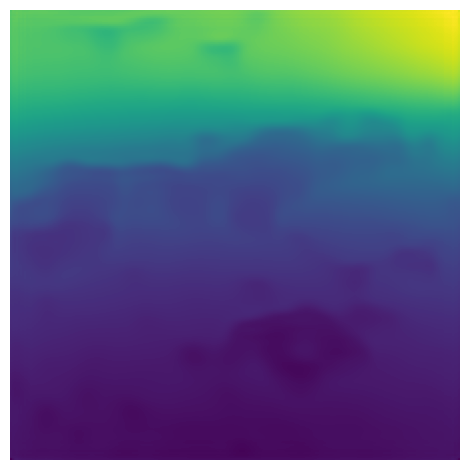

In [21]:
save_predictions(out, 'test_pred.jpg')

In [6]:
### MAKE TRANSFORMS ###

train_transforms = {
    "rgb": transforms.Compose(
        [transforms.ToTensor(), transforms.Resize((224, 224))]
    ),
    "semseg": transforms.Compose(
        [
            transforms.PILToTensor(),
            transforms.Resize((224, 224)),
            FirstChannelTransform(),
            LongTransform(),
        ]
    ),
}
target_transform = transforms.Compose(
    [transforms.PILToTensor(), transforms.Resize((224, 224))]
)

### MAKE DATASETS ###

val_dataset = MultiModalDataset(
    root_dir=config.val_dir,
    input_tasks=in_domains,
    output_task=out_domains[0],
    train_transform=train_transforms,
    target_transofrm=target_transform,
)


In [7]:
sample_dict, target = val_dataset[0]

In [8]:
for k, v in sample_dict.items():
    sample_dict[k] = v.unsqueeze(0)

In [9]:
out = model(sample_dict, return_all_layers=True)

In [90]:
pred = out['depth'][0][0].detach()

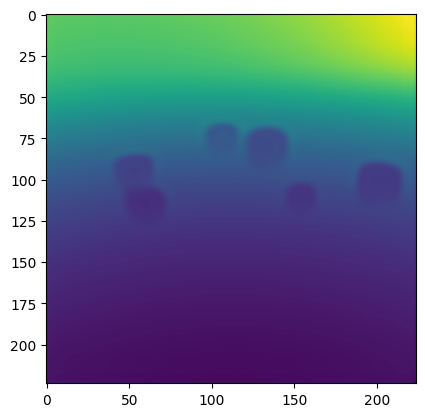

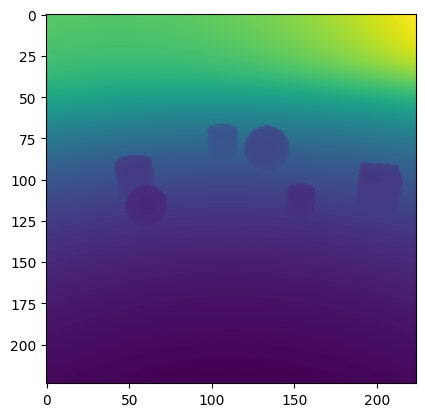

In [10]:
for i in range(1):
    sample_dict, target = val_dataset[i]
    for k, v in sample_dict.items():
        sample_dict[k] = v.unsqueeze(0)
    
    with torch.no_grad():
        out = model(sample_dict, return_all_layers=True)
    pred = out['depth'][0][0].detach()
    target = target[0]
    plt.imshow(pred.numpy())
    plt.show()
    plt.imshow(target.numpy())
    plt.show()

In [11]:
np.save('test.npy', target.numpy())

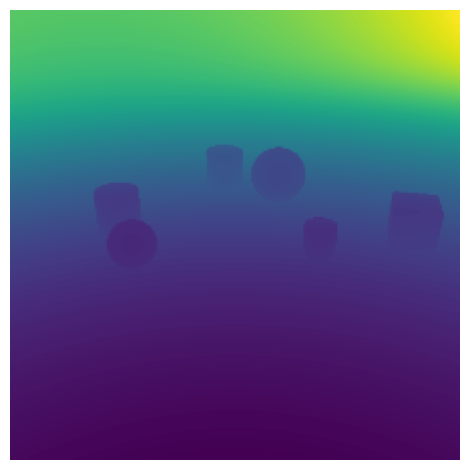

In [17]:
plt.imshow(target.numpy())
plt.axis('off')
plt.tight_layout()
plt.savefig('test.jpg')

In [50]:
notr_dataset = MultiModalDataset(
    root_dir=config.val_dir,
    input_tasks=in_domains,
    output_task=out_domains[0],
    train_transform=train_transforms,
    target_transofrm=None,
)

In [60]:
d, t = notr_dataset[0]

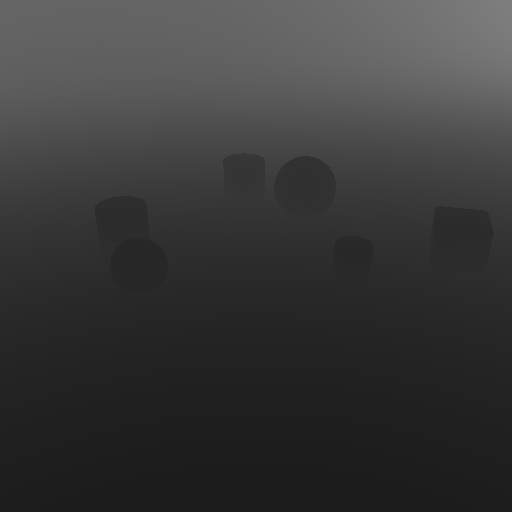

In [62]:
t.convert('L')
t

In [71]:
np.array(t).shape

(512, 512)

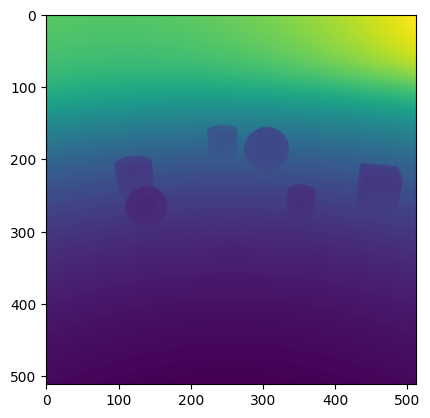

In [56]:
plt.imshow(np.array(t))